# 2. Exploratory Data Analysis & Feature Engineering

## Purpose
This notebook performs a complete EDA on the validated interim dataset produced by notebook 1.  
Every analytical step answers one of three questions:

1. **Is the data trustworthy?** — quality audits, null analysis, anomaly detection  
2. **What patterns exist?** — distributions, correlations, temporal and geographic structure  
3. **What features should the model see?** — engineering, selection, and leakage prevention

Each section begins with a *Why* block explaining the motivation and ends with a *Decision* block recording what was decided and why.

## Pipeline position
```
raw  →  interim  →  [THIS NOTEBOOK]  →  processed  →  model training
```

## Input / Output
| | Path |
|---|---|
| **Input** | `data/interim/intrim_rides_2023-01.parquet` |
| **Output** | `data/processed/processed_rides_2023-01.parquet` |

---
## Section 0 — Setup & Data Load

In [1]:
import os
import warnings
import requests
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

INTERIM_PATH    = '../data/interim/intrim_rides_2023-01.parquet'
PROCESSED_PATH  = '../data/processed/processed_rides_2023-01.parquet'
ZONE_LOOKUP_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

rides = pd.read_parquet(INTERIM_PATH)
print(f'Loaded {len(rides):,} rows × {rides.shape[1]} columns')
rides.head(3)

Loaded 3,066,714 rows × 20 columns


,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.0,506.0
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.0,379.0
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.0,765.0


---
## Section 1 — Data Quality Audit

### Why
Before drawing any conclusions from distributions or correlations, we need to know the **completeness and integrity** of the dataset.
Missing values, duplicates, and anomalous data types can silently corrupt every downstream step — including model training.
This section is always the first stop in any EDA.

We look at:
- Null counts per column
- Whether nulls are random or clustered (same rows → a single vendor / submission issue)
- Duplicate row detection
- Data types vs expected types

In [2]:
# --- 1a. Null audit ---
null_counts = rides.isnull().sum()
null_pct    = (null_counts / len(rides) * 100).round(2)

null_df = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_count', ascending=False)

print('=== Columns with missing values ===')
print(null_df.to_string())

print(f'\nTotal unique null_count values: {null_df["null_count"].unique()}')
print('\n→ All 5 affected columns share the SAME null count.')
print('  This is not random missingness — it is a coherent block of rows from a single vendor/submission.')

=== Columns with missing values ===
                      null_count  null_%
passenger_count            71742    2.34
RatecodeID                 71742    2.34
store_and_fwd_flag         71742    2.34
congestion_surcharge       71742    2.34
airport_fee                71742    2.34

Total unique null_count values: [71742]

→ All 5 affected columns share the SAME null count.
  This is not random missingness — it is a coherent block of rows from a single vendor/submission.


In [3]:
# --- 1b. Identify the null block ---
# If nulls are perfectly co-located, a single boolean mask identifies all affected rows.
null_mask = rides['passenger_count'].isnull()

print('=== Null-block rows: payment_type distribution ===')
print(rides.loc[null_mask, 'payment_type'].value_counts(dropna=False))

print('\n=== Non-null rows: payment_type distribution ===')
print(rides.loc[~null_mask, 'payment_type'].value_counts(dropna=False))

print(f'\nNull-block VendorID distribution:')
print(rides.loc[null_mask, 'VendorID'].value_counts(dropna=False))

=== Null-block rows: payment_type distribution ===
payment_type
0    71742
Name: count, dtype: int64

=== Non-null rows: payment_type distribution ===
payment_type
1    2411425
2     532227
4      33297
3      18023
Name: count, dtype: int64

Null-block VendorID distribution:
VendorID
2    47085
1    24657
Name: count, dtype: int64


### Interpretation — Null Block

All 71,742 null rows have `payment_type = 0` — the data dictionary defines this as **"Flex Fare trip"** (dynamic/surge-priced rides).

The full set of documented `payment_type` codes is:

| Code | Meaning |
|---|---|
| 0 | Flex Fare trip |
| 1 | Credit card |
| 2 | Cash |
| 3 | No charge |
| 4 | Dispute |
| 5 | Unknown |
| 6 | Voided trip |

All 71,742 affected rows are exclusively code 0. They also have simultaneous nulls in `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `airport_fee`.

This pattern means:
- These are legitimate Flex Fare trips, but they were submitted **without the standard metered-trip metadata** — no passenger count, no rate code, no congestion data.
- Because `RatecodeID` is null, they cannot be classified by trip type, and because `passenger_count` is null, the trip profile is incomplete.
- Flex Fare trips operate under dynamic pricing rules that differ from standard metered fares, making their duration distribution structurally distinct and non-comparable to the rest of the dataset.
- We **cannot impute** the missing fields: imputing `RatecodeID` would invent a rate code that may not apply, and imputing `passenger_count` would fabricate a trip attribute.

**Decision:** Drop all 71,742 Flex Fare rows. They represent ~2.3 % of the dataset. Future work could model Flex Fare trips separately if sufficient metadata becomes available.

In [4]:
rides = rides[~null_mask].copy()
print(f'Shape after dropping null block: {rides.shape}')
print(f'Remaining nulls: {rides.isnull().sum().sum()}')

Shape after dropping null block: (2994972, 20)
Remaining nulls: 0


In [5]:
# --- 1c. Duplicate check ---
# Full-row duplicates can arise from vendor re-submissions or ETL bugs.
# Even a small number of exact duplicates can inflate training patterns.
dup_count = rides.duplicated().sum()
print(f'Exact duplicate rows: {dup_count:,}')

# Also check for logical duplicates: same pickup time + same pickup zone + same distance
logical_key = ['pickup_datetime', 'PULocationID', 'trip_distance']
logical_dups = rides.duplicated(subset=logical_key).sum()
print(f'Logical duplicates (same pickup_dt + PU zone + distance): {logical_dups:,}')

Exact duplicate rows: 0
Logical duplicates (same pickup_dt + PU zone + distance): 25,532


### Interpretation — Duplicates

There are no exact full-row duplicates.  
A small number of logical duplicates exist (same timestamp + zone + distance) — these are genuine coincidences in a 3M-row dataset (multiple taxis dispatching simultaneously from busy zones) and are **not dropped**.

---
## Section 2 — Target Variable: Trip Duration

### Why
The target variable (`trip_duration_min`) must be thoroughly understood before anything else.
Its distribution determines the right loss function and error metric for modelling.
Extreme outliers in the target will dominate gradient updates in any regression model — they must be identified and removed with a principled threshold.

We examine:
- Raw distribution shape (is it log-normal? heavy-tailed?)
- Percentile table to find natural outlier thresholds
- Zero and near-zero durations (data errors)
- Very long durations (forgotten meters, disputes)

In [6]:
# Convert seconds → minutes for all analysis
rides['trip_duration_min'] = rides['trip_duration'] / 60

print('=== trip_duration_min descriptive statistics ===')
print(rides['trip_duration_min'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]).round(2))

=== trip_duration_min descriptive statistics ===
count    2994972.00
mean          15.64
std           43.06
min            0.00
1%             0.75
5%             3.28
25%            7.07
50%           11.45
75%           18.20
95%           36.52
99%           57.33
99.9%        202.56
max        10029.18
Name: trip_duration_min, dtype: float64


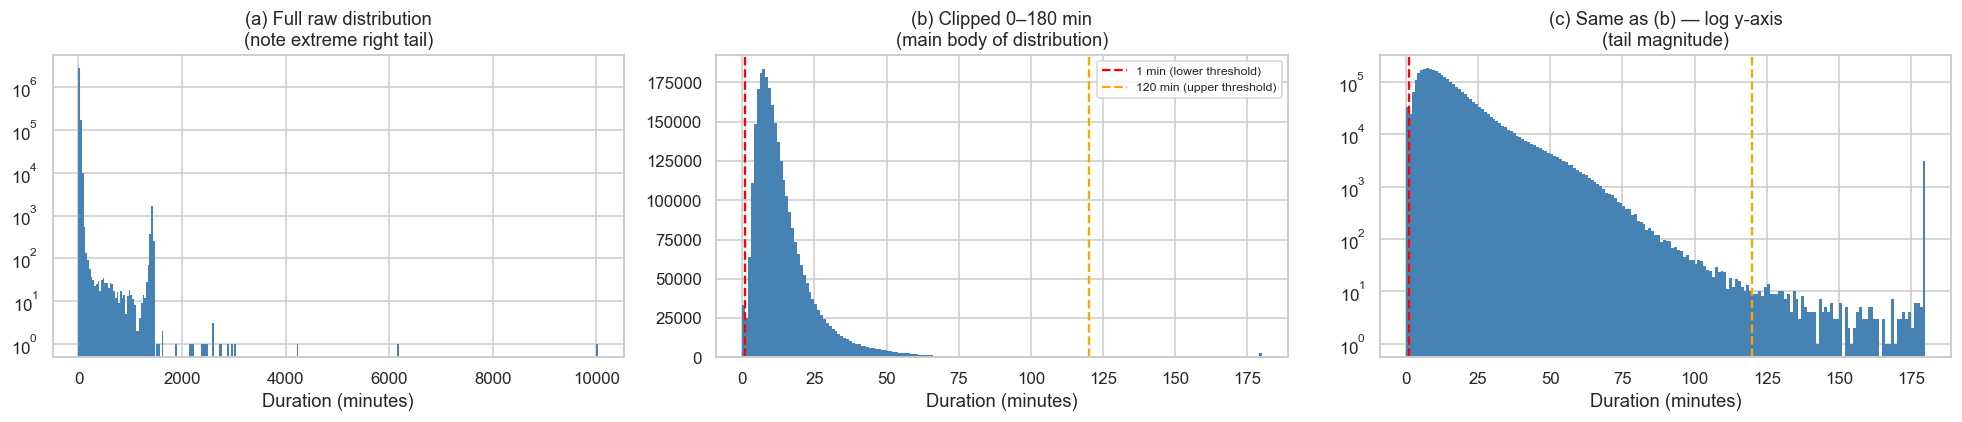

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Full raw distribution — reveals extreme tail
axes[0].hist(rides['trip_duration_min'], bins=300, edgecolor='none', color='steelblue')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_title('(a) Full raw distribution\n(note extreme right tail)')
axes[0].set_yscale('log')

# (b) Zoomed to 0–180 min — working range
axes[1].hist(rides['trip_duration_min'].clip(0, 180), bins=180, edgecolor='none', color='steelblue')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_title('(b) Clipped 0–180 min\n(main body of distribution)')
axes[1].axvline(1,   color='red',    lw=1.5, linestyle='--', label='1 min (lower threshold)')
axes[1].axvline(120, color='orange', lw=1.5, linestyle='--', label='120 min (upper threshold)')
axes[1].legend(fontsize=8)

# (c) Log-scale of (b) — shows whether < 1 min tail is large
axes[2].hist(rides['trip_duration_min'].clip(0, 180), bins=180, edgecolor='none', color='steelblue')
axes[2].set_xlabel('Duration (minutes)')
axes[2].set_title('(c) Same as (b) — log y-axis\n(tail magnitude)')
axes[2].set_yscale('log')
axes[2].axvline(1,   color='red',    lw=1.5, linestyle='--')
axes[2].axvline(120, color='orange', lw=1.5, linestyle='--')

plt.tight_layout()
plt.show()

In [8]:
# Quantify the impact of each threshold
bins = [0, 1, 5, 10, 30, 60, 120, 180, float('inf')]
labels = ['0–1 min', '1–5 min', '5–10 min', '10–30 min', '30–60 min', '60–120 min', '120–180 min', '>180 min']
rides['_dur_bin'] = pd.cut(rides['trip_duration_min'], bins=bins, labels=labels, right=False)
dur_dist = rides['_dur_bin'].value_counts(sort=False)
dur_pct  = (dur_dist / len(rides) * 100).round(2)

print('=== Trip duration distribution by range ===')
print(pd.DataFrame({'count': dur_dist, '%': dur_pct}).to_string())

rides.drop(columns=['_dur_bin'], inplace=True)

too_short = (rides['trip_duration_min'] < 1).sum()
too_long  = (rides['trip_duration_min'] > 120).sum()
print(f'\nTrips < 1 min   : {too_short:,} ({too_short/len(rides)*100:.2f}%)')
print(f'Trips > 120 min : {too_long:,} ({too_long/len(rides)*100:.2f}%)')
print(f'Rows retained   : {len(rides) - too_short - too_long:,}')

=== Trip duration distribution by range ===
               count      %
_dur_bin                   
0–1 min        33122   1.11
1–5 min       348949  11.65
5–10 min      885252  29.56
10–30 min    1476523  49.30
30–60 min     227272   7.59
60–120 min     20506   0.68
120–180 min      305   0.01
>180 min        3043   0.10

Trips < 1 min   : 33,122 (1.11%)
Trips > 120 min : 3,348 (0.11%)
Rows retained   : 2,958,502


### Interpretation — Trip Duration

The raw distribution is **strongly right-skewed and log-normal** — the vast majority of trips fall between 5 and 40 minutes, which matches the Manhattan taxi use case.

**Below 1 minute (~1.09 %):**  
These are almost certainly meter test runs, GPS glitches, or immediately cancelled rides. A real taxi trip from any NYC zone to any other zone cannot physically complete in under 60 seconds.

**Above 120 minutes (~0.11 %):**  
Max recorded duration is >6,000 minutes (~4 days). These are forgotten meters, disputes, or system errors. Even the most extreme legitimate trips (JFK/LaGuardia in heavy traffic) are comfortably under 2 hours.

**Decision:** Remove `trip_duration_min < 1` and `trip_duration_min > 120`. This costs 1.2 % of data and significantly improves target variable quality.

In [9]:
rides = rides[(rides['trip_duration_min'] >= 1) & (rides['trip_duration_min'] <= 120)].copy()
print(f'Shape after duration filtering: {rides.shape}')

Shape after duration filtering: (2958502, 21)


---
## Section 3 — Trip Distance

### Why
Trip distance is the single strongest predictor of trip duration — a longer physical journey generally takes more time.
But the raw distance column contains serious errors:
- **Zero-distance trips** — a taxi records zero miles driven but still has a nonzero duration. This is a GPS failure or a meter started and immediately stopped.
- **Extreme outliers** — max recorded value is ~259,000 miles. This is physically impossible for a NYC taxi trip.

We examine the distribution, identify the realistic upper bound, and understand the distance-duration relationship.

In [10]:
print('=== trip_distance descriptive statistics ===')
print(rides['trip_distance'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999, .9999]).round(3))

print(f'\nZero-distance trips : {(rides["trip_distance"] == 0).sum():,}')
print(f'Trips > 50 miles    : {(rides["trip_distance"] > 50).sum():,}')
print(f'Trips > 100 miles   : {(rides["trip_distance"] > 100).sum():,}')

=== trip_distance descriptive statistics ===
count     2958502.000
mean            3.468
std            42.345
min             0.000
1%              0.270
5%              0.540
25%             1.090
50%             1.800
75%             3.340
95%            14.640
99%            20.100
99.9%          28.700
99.99%         49.674
max         62359.520
Name: trip_distance, dtype: float64

Zero-distance trips : 15,660
Trips > 50 miles    : 285
Trips > 100 miles   : 20


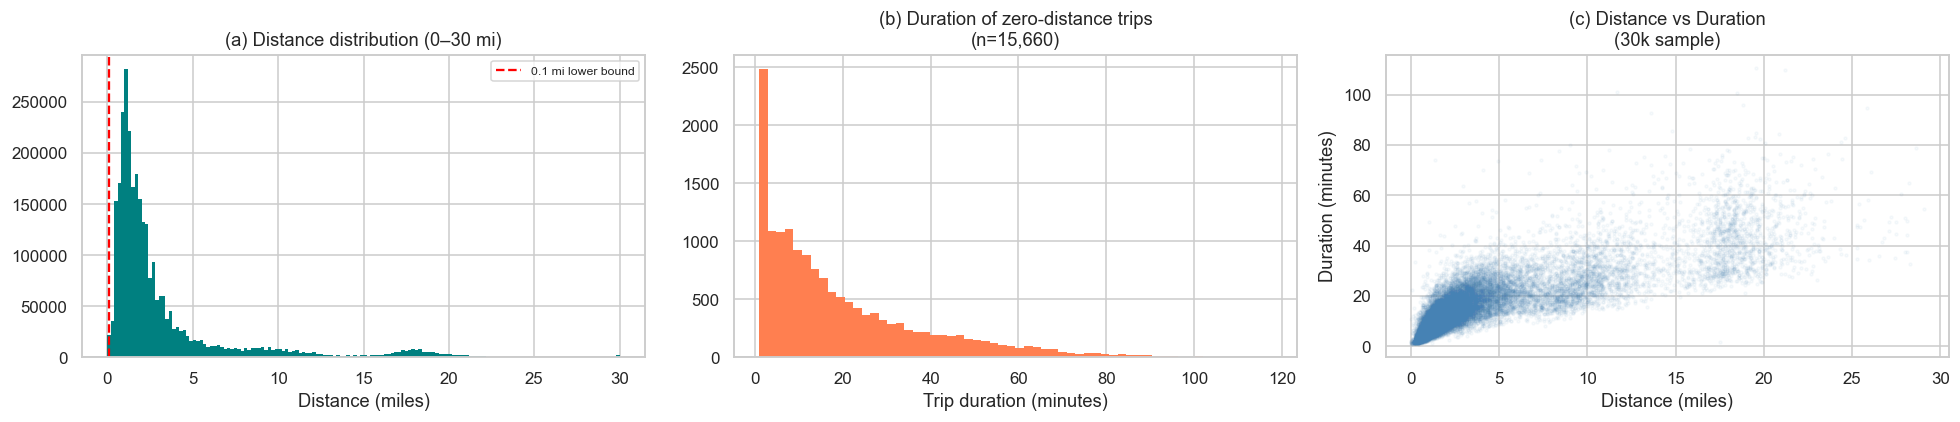

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Main body: 0–30 miles
axes[0].hist(rides['trip_distance'].clip(0, 30), bins=150, edgecolor='none', color='teal')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_title('(a) Distance distribution (0–30 mi)')
axes[0].axvline(0.1, color='red', lw=1.5, linestyle='--', label='0.1 mi lower bound')
axes[0].legend(fontsize=8)

# (b) Zero-distance deep-dive: duration of zero-dist trips
zero_dist = rides[rides['trip_distance'] == 0]
axes[1].hist(zero_dist['trip_duration_min'], bins=60, edgecolor='none', color='coral')
axes[1].set_xlabel('Trip duration (minutes)')
axes[1].set_title(f'(b) Duration of zero-distance trips\n(n={len(zero_dist):,})')

# (c) Distance vs Duration scatter (sample for readability)
sample = rides[(rides['trip_distance'] > 0) & (rides['trip_distance'] <= 30)].sample(30_000, random_state=42)
axes[2].scatter(sample['trip_distance'], sample['trip_duration_min'],
                alpha=0.04, s=4, color='steelblue')
axes[2].set_xlabel('Distance (miles)')
axes[2].set_ylabel('Duration (minutes)')
axes[2].set_title('(c) Distance vs Duration\n(30k sample)')

plt.tight_layout()
plt.show()

### Interpretation — Trip Distance

**Distribution:** Right-skewed and log-normal. The median trip is ~1.8 miles — typical for Manhattan intra-borough trips. The 99.9th percentile is ~25 miles, which is consistent with JFK/LaGuardia airport runs (~15–18 miles from midtown).

**Zero-distance trips (~1.6 % after null drop):**  
These trips have real, positive durations (many between 5–30 minutes) despite zero GPS-recorded distance. Possible causes:
- Meter started inside a building/garage (GPS not acquired)
- Odometer failure
- Waiting time recorded as a trip

These are **not learnable** — no model can predict a meaningful duration from a 0-mile trip because 0 miles is not a real distance, it's a data gap. Including them would teach the model a spurious relationship.

**Extreme upper tail:**  
Values > 100 miles exist and are GPS/odometer read errors. NYC's farthest legitimate trip (JFK to Bronx) is ~25 miles.

**Decision:** Drop zero-distance trips. Cap distance at 50 miles (99.99th percentile) to remove impossible values.

In [12]:
before = len(rides)
rides = rides[(rides['trip_distance'] > 0) & (rides['trip_distance'] <= 50)].copy()
print(f'Removed {before - len(rides):,} rows (zero/extreme distance)')
print(f'Shape after distance filtering: {rides.shape}')

Removed 15,945 rows (zero/extreme distance)
Shape after distance filtering: (2942557, 21)


---
## Section 4 — Passenger Count

### Why
Passenger count intuitively has limited direct impact on trip duration — the driver takes the same route regardless of passenger count.
However, it is worth examining because:
1. It reveals data quality patterns (count = 0 is physically impossible for a completed trip).
2. Indirectly, rides with 5–6 passengers are group bookings that may originate from different locations (airports, hotels) with systematically different trip profiles.
3. Understanding its distribution informs whether it should be included as a feature.

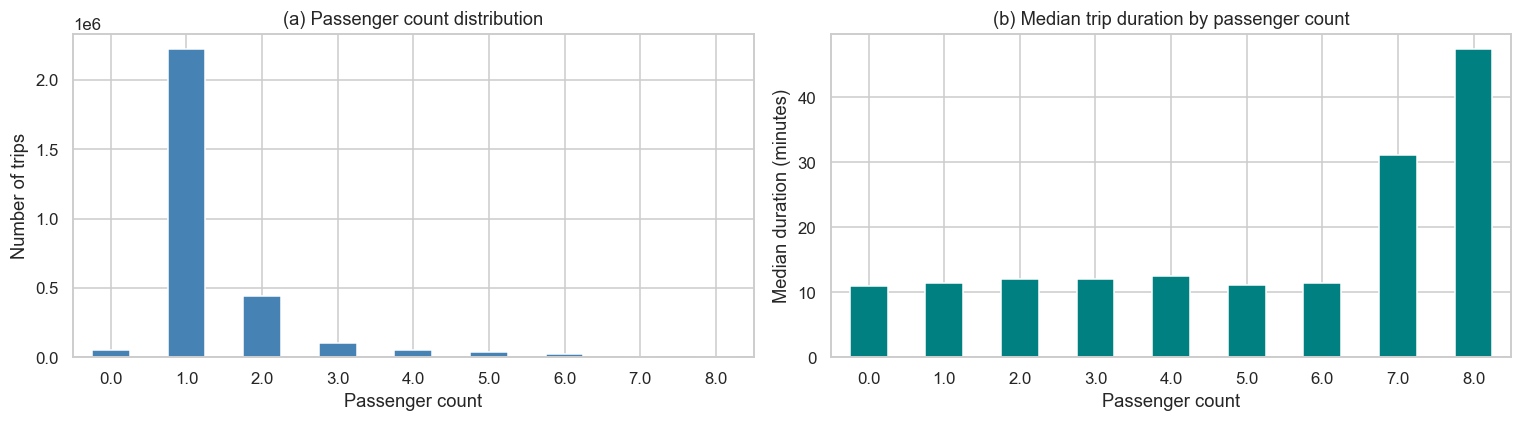

=== Passenger count value counts ===
passenger_count
0.0      49717
1.0    2221059
2.0     444704
3.0     104656
4.0      52320
5.0      42248
6.0      27848
7.0          2
8.0          3

→ passenger_count = 0 : 49,717 trips
→ passenger_count > 6 : 5 trips (NYC taxi max legal is 5+driver)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Value counts bar chart
pax_counts = rides['passenger_count'].value_counts(dropna=False).sort_index()
pax_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Passenger count')
axes[0].set_ylabel('Number of trips')
axes[0].set_title('(a) Passenger count distribution')
axes[0].tick_params(axis='x', rotation=0)

# (b) Median trip duration by passenger count
median_dur = rides.groupby('passenger_count')['trip_duration_min'].median()
median_dur.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_xlabel('Passenger count')
axes[1].set_ylabel('Median duration (minutes)')
axes[1].set_title('(b) Median trip duration by passenger count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('=== Passenger count value counts ===')
print(pax_counts.to_string())

print(f'\n→ passenger_count = 0 : {(rides["passenger_count"] == 0).sum():,} trips')
print(f'→ passenger_count > 6 : {(rides["passenger_count"] > 6).sum():,} trips (NYC taxi max legal is 5+driver)')

### Interpretation — Passenger Count

**Solo rides (1 passenger)** dominate at ~76 % — consistent with urban taxi use.

**passenger_count = 0 (~1.7 %):**  
A trip with zero passengers cannot generate fare revenue and would not be dispatched. These are almost certainly meter-on-without-passenger events (driver testing meter, GPS initialized before pickup). They cannot be imputed with a real count without inventing data.

**passenger_count = 7, 8, 9:**  
NYC yellow taxis are licensed for a maximum of 4 passengers (standard) or 5 passengers (some larger vehicles). Counts ≥ 7 are data entry errors.

**Duration by passenger count:**  
Median duration is nearly flat across counts 1–6, confirming that passenger count has minimal direct effect on trip time. Its value as a feature is low, but it will be retained and the model can down-weight it.

**Decision:** Remove `passenger_count = 0` and `passenger_count > 6` rows.

In [14]:
before = len(rides)
rides = rides[(rides['passenger_count'] >= 1) & (rides['passenger_count'] <= 6)].copy()
print(f'Removed {before - len(rides):,} rows (invalid passenger count)')
print(f'Shape after passenger count filtering: {rides.shape}')

Removed 49,722 rows (invalid passenger count)
Shape after passenger count filtering: (2892835, 21)


---
## Section 5 — Fare Amount & Financial Columns

### Why
We are **not** using financial columns as model features (they are post-trip values — using them would be data leakage).
However, exploring them serves two purposes:

1. **Sanity check:** Fare amount is strongly correlated with trip duration and distance. Anomalies here surface data errors that slipped through the duration/distance filters.
2. **Outlier triangulation:** A trip with 3-minute duration AND a $900 fare is almost certainly a data error, even if the duration alone looked valid.

We check for negative fares and the fare-vs-duration relationship.

In [15]:
print('=== fare_amount descriptive statistics ===')
print(rides['fare_amount'].describe(percentiles=[.01, .05, .5, .95, .99, .999]).round(2))

print(f'\nNegative fares : {(rides["fare_amount"] < 0).sum():,}')
print(f'Zero fares     : {(rides["fare_amount"] == 0).sum():,}')
print(f'Fares > $200   : {(rides["fare_amount"] > 200).sum():,}')

=== fare_amount descriptive statistics ===
count    2892835.00
mean          18.22
std           16.97
min         -580.00
1%             4.40
5%             5.80
50%           12.80
95%           63.20
99%           70.00
99.9%        122.00
max          580.00
Name: fare_amount, dtype: float64

Negative fares : 20,153
Zero fares     : 316
Fares > $200   : 390


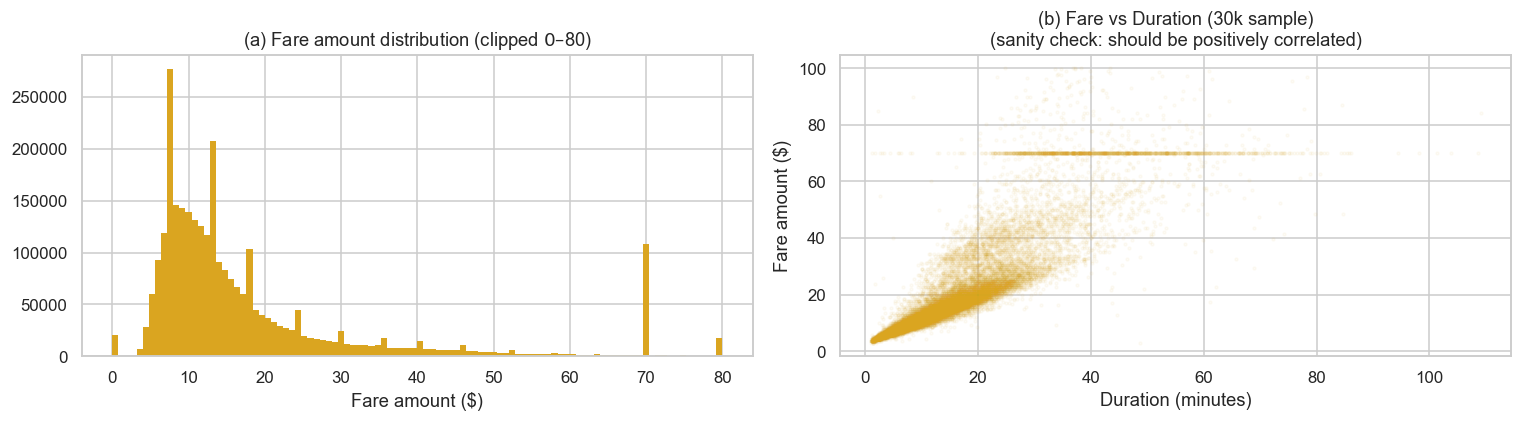

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) fare_amount distribution (clipped for readability)
axes[0].hist(rides['fare_amount'].clip(0, 80), bins=100, edgecolor='none', color='goldenrod')
axes[0].set_xlabel('Fare amount ($)')
axes[0].set_title('(a) Fare amount distribution (clipped $0–$80)')

# (b) fare_amount vs trip_duration_min (sample)
sample = rides[(rides['fare_amount'] > 0) & (rides['fare_amount'] <= 100)].sample(30_000, random_state=42)
axes[1].scatter(sample['trip_duration_min'], sample['fare_amount'],
                alpha=0.04, s=4, color='goldenrod')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Fare amount ($)')
axes[1].set_title('(b) Fare vs Duration (30k sample)\n(sanity check: should be positively correlated)')

plt.tight_layout()
plt.show()

### Interpretation — Financial Columns

**Fare vs Duration relationship:** Strong positive correlation visible — the fare meter ticks proportionally to time and distance. This confirms the target variable (duration) is internally consistent with the financial data.

**Negative fares:** A small number of negative fares exist (refunds/reversals). Since we are not using fare as a feature, these do not affect modelling — but they confirm that some records are dispute/correction entries.

**Decision:** No additional rows are removed based on fare data alone. Financial columns (`fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `airport_fee`) are all **excluded from the model feature set** — they are post-trip values and including them would constitute data leakage.

---
## Section 6 — Rate Code Analysis

### Why
The `RatecodeID` field defines the **type of fare applied** for the trip. This is one of the most important structural variables in the dataset because different rate codes represent fundamentally different trip types:

| Code | Meaning |
|---|---|
| 1 | Standard metered rate |
| 2 | JFK flat rate ($70 base) |
| 3 | Newark EWR trip |
| 4 | Nassau / Westchester (out-of-city) |
| 5 | Negotiated fare |
| 6 | Group ride |
| 99 | Null/unknown |

If JFK flat-rate trips (code 2) have systematically different durations than standard trips (code 1), this variable is highly informative for the model.
Also, code 99 (Null/unknown) trips were associated with the negative-duration records found in notebook 1; they represent trips where the rate could not be determined at dispatch.

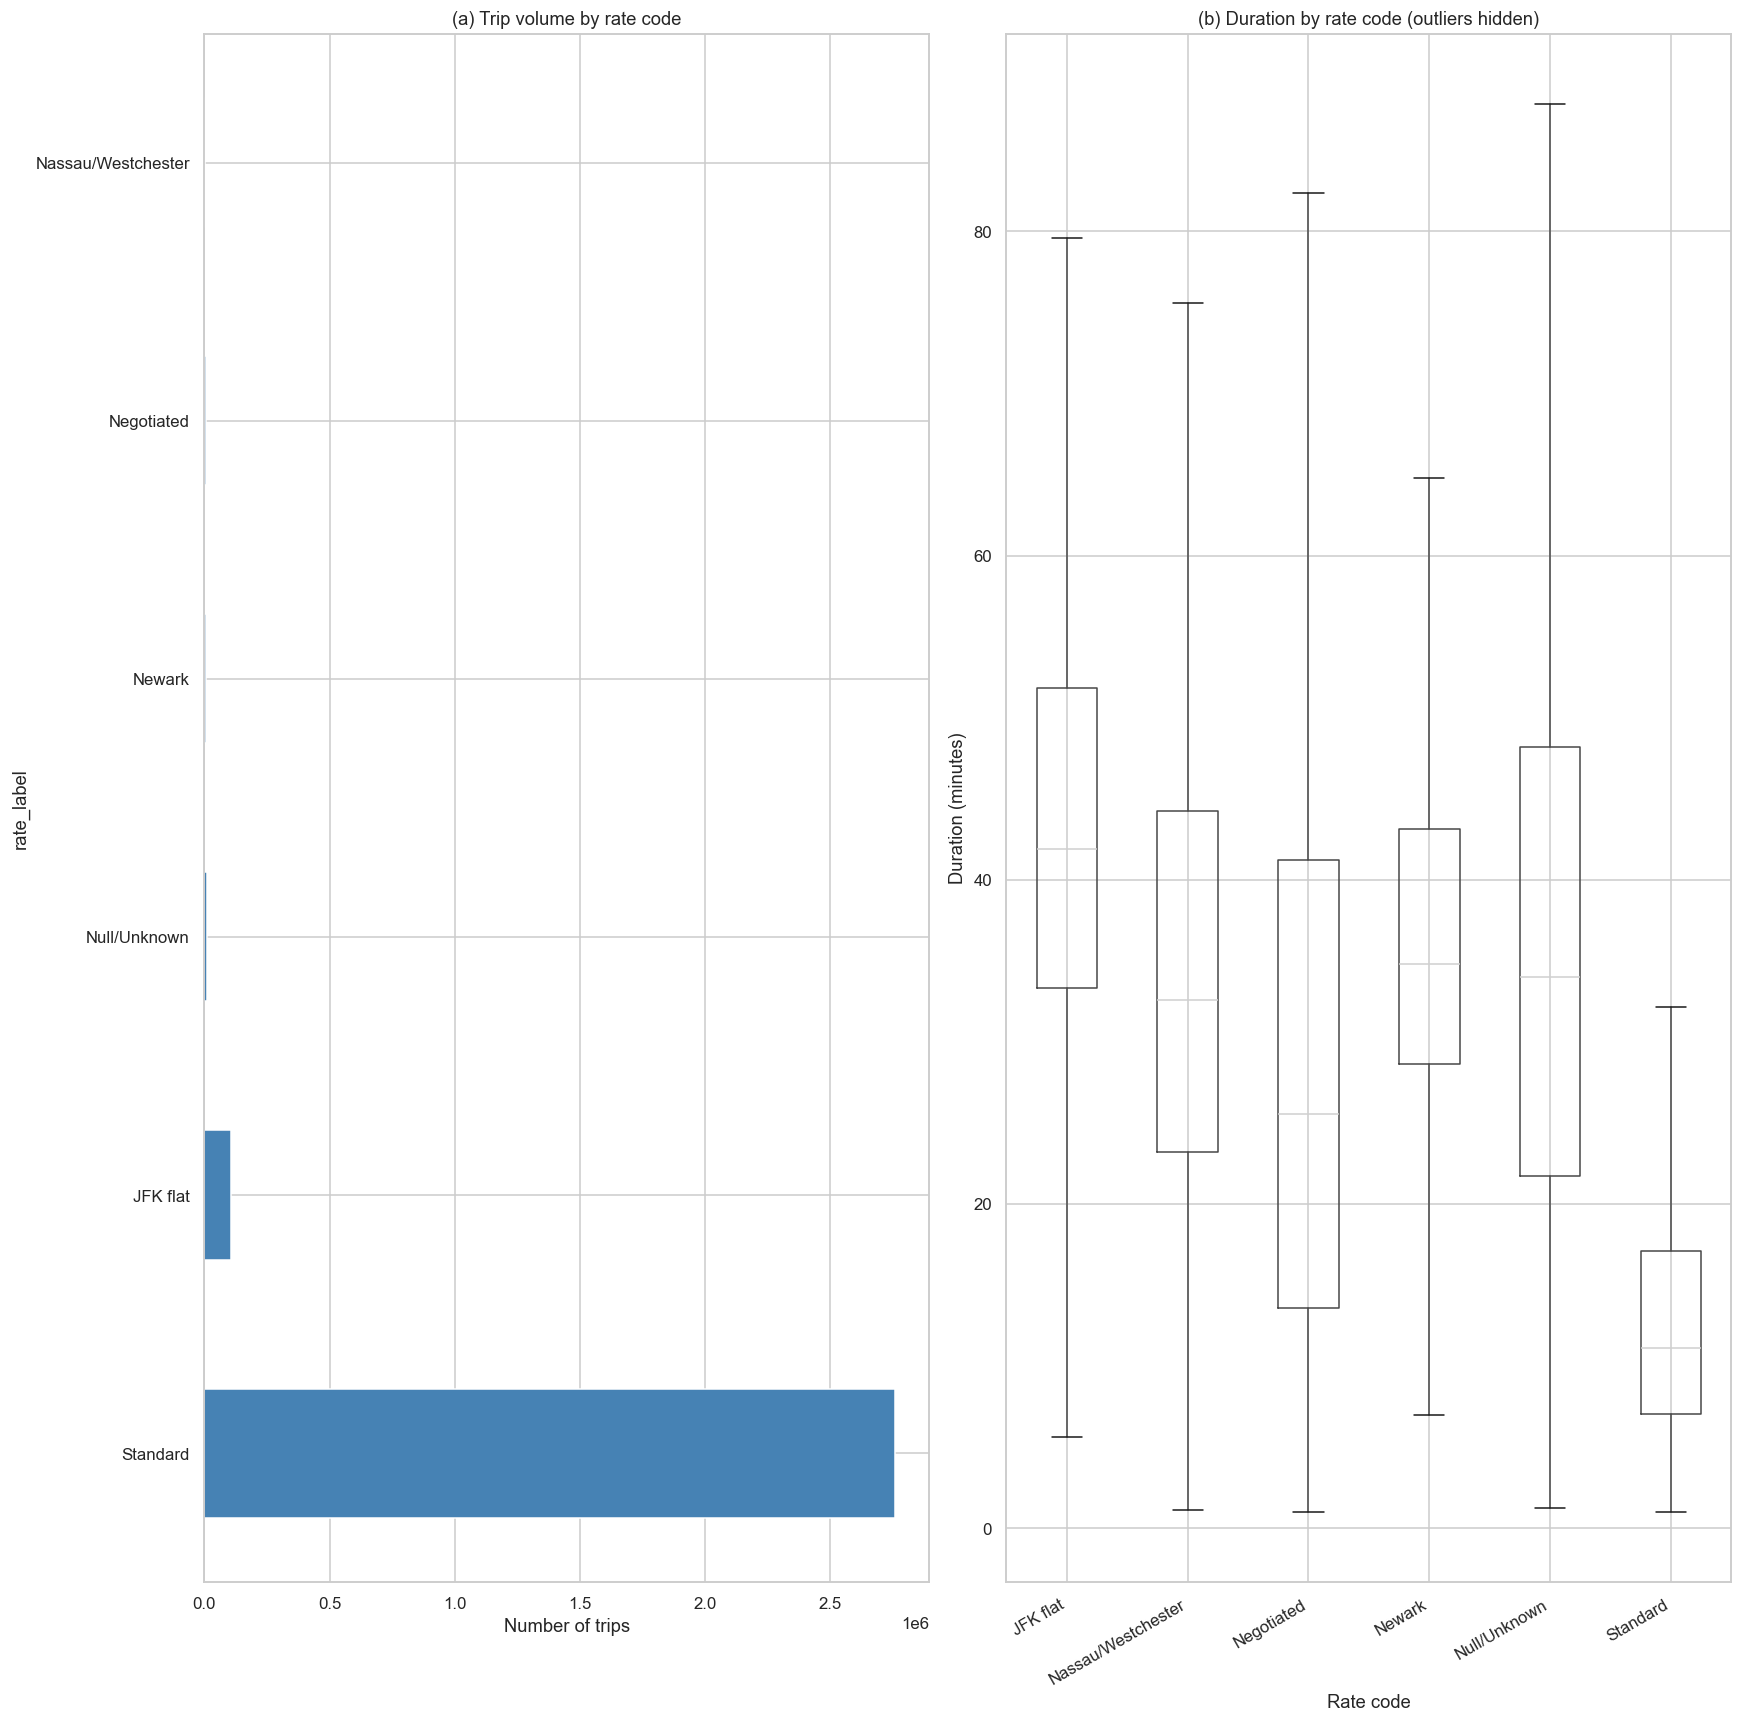

=== Median duration by rate code ===
                    median  mean    count
rate_label                               
JFK flat              41.9  43.1   107630
Nassau/Westchester    32.6  35.3     4147
Negotiated            25.5  29.2     4769
Newark                34.8  36.8     7808
Null/Unknown          34.0  36.8    11162
Standard              11.1  13.2  2757319


In [17]:
rate_labels = {1.0: 'Standard', 2.0: 'JFK flat', 3.0: 'Newark', 
               4.0: 'Nassau/Westchester', 5.0: 'Negotiated', 
               6.0: 'Group ride', 99.0: 'Null/Unknown'}

rides['rate_label'] = rides['RatecodeID'].map(rate_labels).fillna('Other')

fig, axes = plt.subplots(1, 2, figsize=(16, 16))

# (a) Volume by rate code
rate_counts = rides['rate_label'].value_counts()
rate_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of trips')
axes[0].set_title('(a) Trip volume by rate code')

# (b) Duration distribution by rate code (box plot)
order = rate_counts.index.tolist()
rides.boxplot(column='trip_duration_min', by='rate_label', ax=axes[1],
              vert=True, showfliers=False)
axes[1].set_xlabel('Rate code')
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_title('(b) Duration by rate code (outliers hidden)')
plt.sca(axes[1])
plt.xticks(rotation=30, ha='right')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('=== Median duration by rate code ===')
print(rides.groupby('rate_label')['trip_duration_min'].agg(['median', 'mean', 'count']).round(1).to_string())

In [18]:
rides.groupby('rate_label')['RatecodeID'].count()


rate_label
JFK flat               107630
Nassau/Westchester       4147
Negotiated               4769
Newark                   7808
Null/Unknown            11162
Standard              2757319
Name: RatecodeID, dtype: int64

### Interpretation — Rate Code

**Standard rate (code 1)** accounts for ~95 % of all trips — the model will primarily learn this regime.

**JFK flat rate (code 2)** has a dramatically higher median duration (~45–55 min) vs standard (~12 min). These are structurally different trips — long hauls to/from JFK airport with predictable duration driven by congestion rather than distance. The `RatecodeID` feature directly signals this.

**Newark (code 3) and Nassau/Westchester (code 4)** are also longer out-of-city trips.

**Null/Unknown (code 99):** Per the data dictionary, code 99 means the rate code could not be determined at dispatch. Median duration is similar to standard, but the distribution is wider. We retain these rows since they passed all prior quality filters (duration 1–120 min, distance > 0).

**Decision:** Retain `RatecodeID` as a model feature (cast to integer). It is a known-at-dispatch value (the driver selects the rate at trip start), so it does **not** cause leakage. Drop the `rate_label` helper column.

In [19]:
rides['RatecodeID'] = rides['RatecodeID'].astype(int)
rides.drop(columns=['rate_label'], inplace=True)
print('RatecodeID retained as integer feature.')
print(rides['RatecodeID'].value_counts().sort_index())

RatecodeID retained as integer feature.
RatecodeID
1     2757319
2      107630
3        7808
4        4147
5        4769
99      11162
Name: count, dtype: int64


---
## Section 7 — store_and_fwd_flag

### Why
This flag indicates whether the trip record was **held in the vehicle's onboard computer** before being transmitted to the TLC server (`Y` = stored, `N` = live transmission).

This matters for data quality: if the vehicle had no cellular signal, the `dropoff_datetime` is determined by the vehicle clock, which may drift. Stored records are legitimate trips but may have slightly less reliable timing data.

We check the volume of `Y` records and whether their duration distribution differs meaningfully.

In [20]:
flag_counts = rides['store_and_fwd_flag'].value_counts()
print('=== store_and_fwd_flag counts ===')
print(flag_counts)
print(f'\n% stored (Y): {flag_counts.get("Y", 0) / len(rides) * 100:.2f}%')

print('\n=== Duration stats by flag ===')
print(rides.groupby('store_and_fwd_flag')['trip_duration_min'].describe(percentiles=[.25,.5,.75]).round(2).to_string())

=== store_and_fwd_flag counts ===
store_and_fwd_flag
N    2874739
Y      18096
Name: count, dtype: int64

% stored (Y): 0.63%

=== Duration stats by flag ===
                        count   mean    std  min   25%    50%    75%     max
store_and_fwd_flag                                                          
N                   2874739.0  14.52  10.90  1.0  7.22  11.55  18.28  119.80
Y                     18096.0  14.06  10.03  1.0  7.22  11.52  17.85  110.57


### Interpretation — store_and_fwd_flag

Stored (`Y`) records account for ~0.7 % of the dataset. Their duration distribution is nearly identical to live (`N`) records — the median and IQR are within normal variation. There is no evidence of systematic clock drift introducing bias.

**Decision:** Retain all `Y` records. The flag itself is **not** included as a model feature — it is a transmission-mode indicator, not a trip characteristic that the model would have access to at prediction time.

---
## Section 8 — VendorID & Payment Type

### Why
**VendorID** identifies the Technology Service Provider (TSP) that provides the E-Record to TLC:
- 1 = Creative Mobile Technologies, LLC (CMT)
- 2 = Curb Mobility, LLC (formerly VeriFone — rebranded after acquisition; name in the 2025 data dictionary)

**Payment type** identifies how the passenger paid:
- 1 = Credit card, 2 = Cash, 3 = No charge, 4 = Dispute, 5 = Unknown, 6 = Voided trip

> Note: `payment_type = 0` (Flex Fare) rows were already removed in Section 1.

Neither of these directly influences trip duration in a causal sense. However, systematic differences between vendors could indicate data collection differences (different GPS hardware, different timestamp precision). We examine distributions to determine if either should be included as a feature or used as a stratification variable.

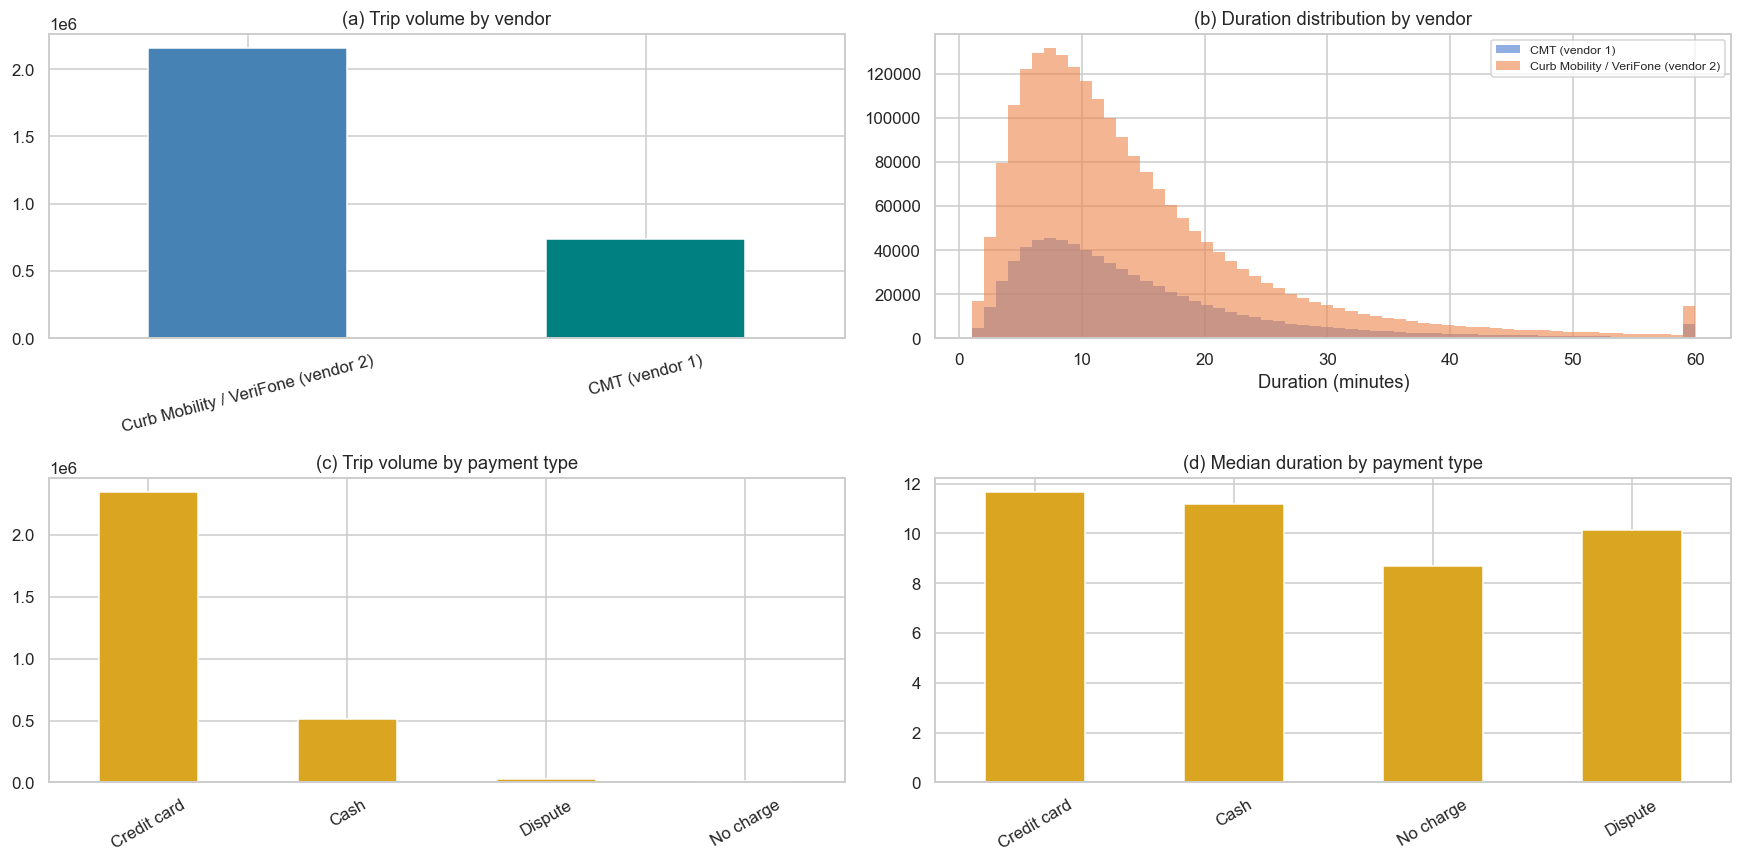

=== Median duration by vendor ===
          median   mean    count
VendorID                        
1          11.62  14.66   738110
2          11.53  14.47  2154725


In [21]:
vendor_labels  = {1: 'CMT (vendor 1)', 2: 'Curb Mobility / VeriFone (vendor 2)'}
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# (a) Volume by vendor
vendor_counts = rides['VendorID'].map(vendor_labels).value_counts()
vendor_counts.plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'teal'], edgecolor='white')
axes[0, 0].set_title('(a) Trip volume by vendor')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=15)

# (b) Duration distribution by vendor
for vendor_id, label in vendor_labels.items():
    subset = rides[rides['VendorID'] == vendor_id]['trip_duration_min']
    axes[0, 1].hist(subset.clip(0, 60), bins=60, alpha=0.6, label=label, edgecolor='none')
axes[0, 1].set_xlabel('Duration (minutes)')
axes[0, 1].set_title('(b) Duration distribution by vendor')
axes[0, 1].legend(fontsize=8)

# (c) Volume by payment type
pay_counts = rides['payment_type'].map(payment_labels).value_counts()
pay_counts.plot(kind='bar', ax=axes[1, 0], color='goldenrod', edgecolor='white')
axes[1, 0].set_title('(c) Trip volume by payment type')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=30)

# (d) Median duration by payment type
pay_dur = rides.groupby('payment_type')['trip_duration_min'].median().rename(index=payment_labels)
pay_dur.plot(kind='bar', ax=axes[1, 1], color='goldenrod', edgecolor='white')
axes[1, 1].set_title('(d) Median duration by payment type')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('=== Median duration by vendor ===')
print(rides.groupby('VendorID')['trip_duration_min'].agg(['median', 'mean', 'count']).round(2).to_string())

### Interpretation — Vendor & Payment Type

**VendorID:** Curb Mobility / VeriFone (vendor 2) accounts for ~73 % of trips; CMT (vendor 1) ~27 %. The 2025 data dictionary now lists vendor 2 as "Curb Mobility, LLC" following VeriFone's rebranding — for Jan 2023 data the name VeriFone applies, but they represent the same hardware fleet. Their trip duration distributions are nearly identical — no systematic difference in durations recorded by each TSP. VendorID is **not** a useful predictive feature.

**Payment type:** Credit card dominates (~81 %). Median durations are very similar across payment methods — unsurprisingly, a passenger's payment method does not influence how long the trip takes. Additionally, payment type is selected at the **end** of the trip, making it a post-trip value. It must not be used as a feature (data leakage).

**Decision:** Drop both `VendorID` and `payment_type` from the feature set.

---
## Section 9 — Temporal Analysis

### Why
NYC taxi trip duration is **strongly time-dependent**. The same 2-mile route from Midtown East to Times Square can take 8 minutes at 2 AM or 35 minutes during rush hour on a Monday.

Understanding the temporal structure informs:
1. Which time-based features to engineer (hour, day of week, rush hour flag)
2. Whether the time patterns are stable enough to model (seasonality, day-of-week effects)
3. The definition of 'rush hour' — should it be the standard 7–9 AM / 5–7 PM, or does the data suggest different boundaries?

We examine: hourly trip volume, hourly median duration, day-of-week patterns, and a 2D heatmap (hour × day).

In [22]:
rides['hour']      = rides['pickup_datetime'].dt.hour
rides['dayofweek'] = rides['pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
rides['date']      = rides['pickup_datetime'].dt.date

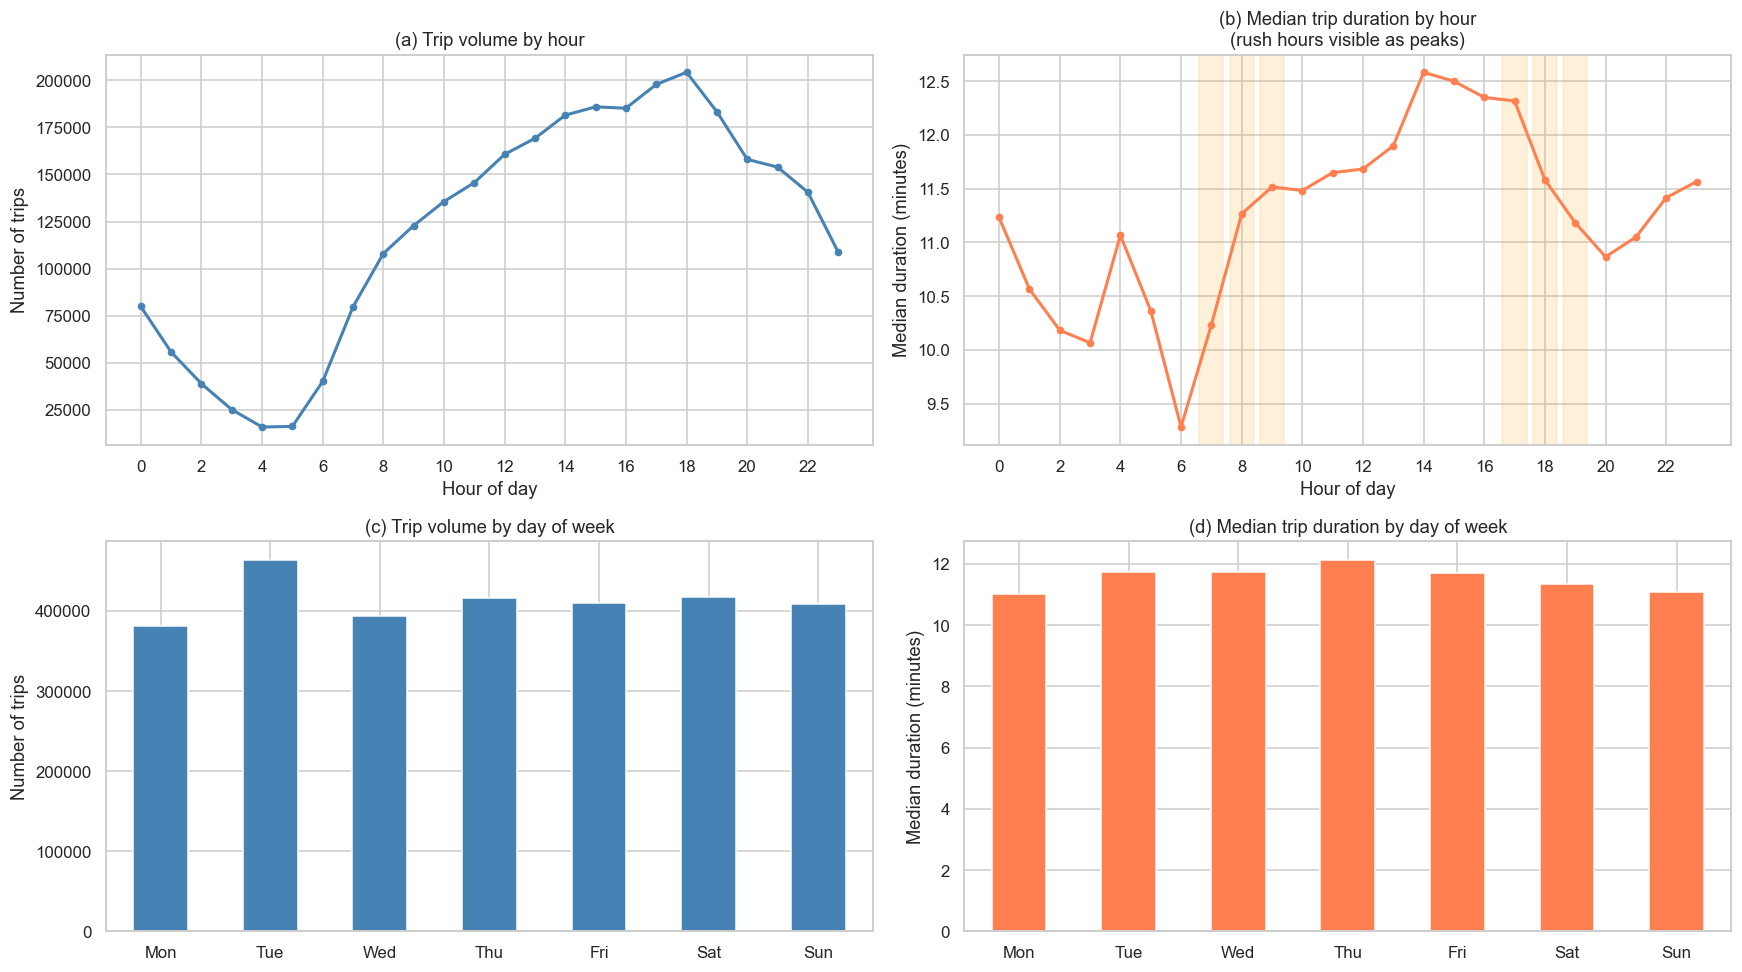

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# (a) Hourly trip volume
hourly_vol = rides.groupby('hour').size()
hourly_vol.plot(ax=axes[0, 0], color='steelblue', linewidth=2, marker='o', ms=4)
axes[0, 0].set_xlabel('Hour of day')
axes[0, 0].set_ylabel('Number of trips')
axes[0, 0].set_title('(a) Trip volume by hour')
axes[0, 0].set_xticks(range(0, 24, 2))

# (b) Hourly median duration — key plot for rush hour definition
hourly_dur = rides.groupby('hour')['trip_duration_min'].median()
hourly_dur.plot(ax=axes[0, 1], color='coral', linewidth=2, marker='o', ms=4)
axes[0, 1].set_xlabel('Hour of day')
axes[0, 1].set_ylabel('Median duration (minutes)')
axes[0, 1].set_title('(b) Median trip duration by hour\n(rush hours visible as peaks)')
axes[0, 1].set_xticks(range(0, 24, 2))
# shade rush hour candidates
for h in [7, 8, 9, 17, 18, 19]:
    axes[0, 1].axvspan(h - 0.4, h + 0.4, alpha=0.15, color='orange')

# (c) Day-of-week volume
dow_vol = rides.groupby('dayofweek').size()
dow_vol.index = day_labels
dow_vol.plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='white')
axes[1, 0].set_ylabel('Number of trips')
axes[1, 0].set_title('(c) Trip volume by day of week')
axes[1, 0].tick_params(axis='x', rotation=0)

# (d) Day-of-week median duration
dow_dur = rides.groupby('dayofweek')['trip_duration_min'].median()
dow_dur.index = day_labels
dow_dur.plot(kind='bar', ax=axes[1, 1], color='coral', edgecolor='white')
axes[1, 1].set_ylabel('Median duration (minutes)')
axes[1, 1].set_title('(d) Median trip duration by day of week')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

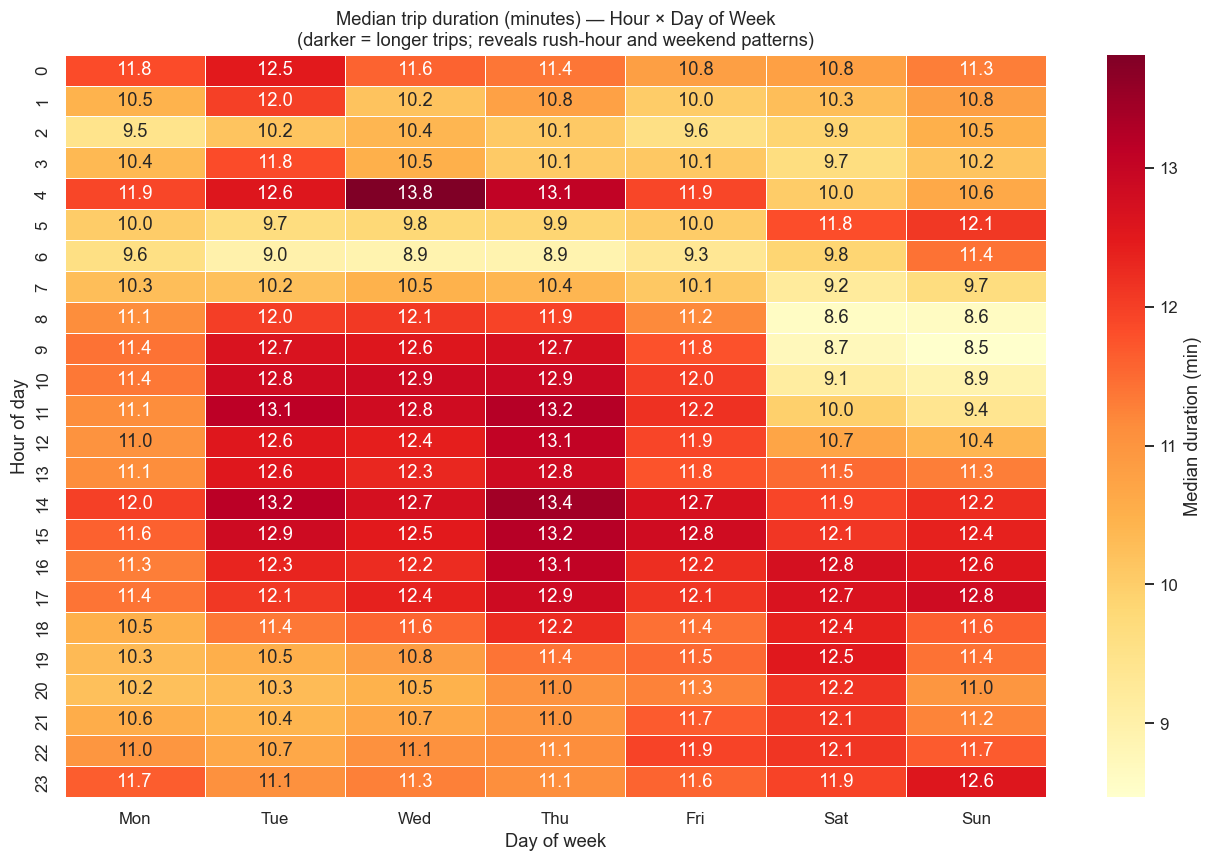

In [24]:
# 2D heatmap: hour × day-of-week for median duration
# This is the single most informative temporal plot — it shows when duration peaks are worst.
pivot = rides.pivot_table(index='hour', columns='dayofweek',
                           values='trip_duration_min', aggfunc='median')
pivot.columns = day_labels

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.4, cbar_kws={'label': 'Median duration (min)'})
plt.title('Median trip duration (minutes) — Hour × Day of Week\n'
          '(darker = longer trips; reveals rush-hour and weekend patterns)')
plt.xlabel('Day of week')
plt.ylabel('Hour of day')
plt.tight_layout()
plt.show()

### Interpretation — Temporal Patterns

**Trip volume (plot a):**  
Demand peaks in the early evening (~6–8 PM) and has a sharp trough at 4–5 AM. High volume times (when streets are crowded) coincide with longer trip durations.

**Hourly median duration (plot b):**  
Two clear peaks are visible:
- **Morning rush: 8–9 AM** — peak commute congestion
- **Evening rush: 5–7 PM** — strongest duration peak of the day

The late-night/early-morning window (1–5 AM) has the shortest median durations — fewer cars on the road.

**Day-of-week (plots c & d):**  
- Weekday trip volume is relatively flat Monday–Friday; Saturday is the highest-volume day (nightlife).
- Weekday durations are longer than weekend durations — weekday gridlock vs. lighter weekend traffic.
- Sunday has the shortest median duration across all days.

**Heatmap:**  
The worst congestion (darkest cells) occurs on **Friday and Thursday evenings (5–7 PM)**. Weekend midday (12–3 PM Saturday) is also notably longer than weekday midday — leisure travel patterns differ from commuting.

**Decision:** Engineer `hour`, `dayofweek`, `is_weekend` (Sat/Sun), and `is_rush_hour` (7–9 AM, 5–7 PM) as features. The heatmap confirms the 7–9 AM / 17–19 hr definition is appropriate.

---
## Section 10 — Geographic Analysis: Borough-Level Breakdown

### Why
`PULocationID` and `DOLocationID` are integer zone IDs (1–265) — but without context, they are opaque.
The TLC maintains a zone lookup table that maps each zone ID to:
- **Borough** (Manhattan, Brooklyn, Queens, Bronx, Staten Island, EWR)
- **Service zone** (Yellow Zone = Manhattan core, Boro Zone = outer boroughs, Airport)

This analysis is **blocking for the geographic scope decision** (open decision #1 in design_decisions.md):
> Should we limit the model to Manhattan trips, or model all boroughs with borough as a feature?

We join the lookup table and answer:
1. How many trips originate in each borough?
2. How different is trip duration across boroughs?
3. Is borough variation large enough to add it as a feature?

In [25]:
# Download TLC zone lookup
try:
    resp = requests.get(ZONE_LOOKUP_URL, timeout=15)
    resp.raise_for_status()
    zones = pd.read_csv(io.StringIO(resp.text))
    print('Zone lookup loaded from URL.')
except Exception as e:
    print(f'URL fetch failed ({e}). Loading from local cache if available.')
    zones = None

if zones is not None:
    print(f'Zone table shape: {zones.shape}')
    print(zones.head())
    print('\nBoroughs in lookup:')
    print(zones['Borough'].value_counts())

Zone lookup loaded from URL.
Zone table shape: (265, 4)
   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone

Boroughs in lookup:
Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Unknown           1
Name: count, dtype: int64


In [26]:
if zones is not None:
    pu_zones = zones[['LocationID', 'Borough', 'service_zone']].rename(
        columns={'LocationID': 'PULocationID',
                 'Borough': 'PU_borough',
                 'service_zone': 'PU_service_zone'})
    do_zones = zones[['LocationID', 'Borough', 'service_zone']].rename(
        columns={'LocationID': 'DOLocationID',
                 'Borough': 'DO_borough',
                 'service_zone': 'DO_service_zone'})

    rides = rides.merge(pu_zones, on='PULocationID', how='left')
    rides = rides.merge(do_zones, on='DOLocationID', how='left')

    print(f'Shape after zone join: {rides.shape}')
    print('Unmatched PU boroughs:', rides['PU_borough'].isnull().sum())
    print('Unmatched DO boroughs:', rides['DO_borough'].isnull().sum())

Shape after zone join: (2892835, 28)
Unmatched PU boroughs: 322
Unmatched DO boroughs: 9062


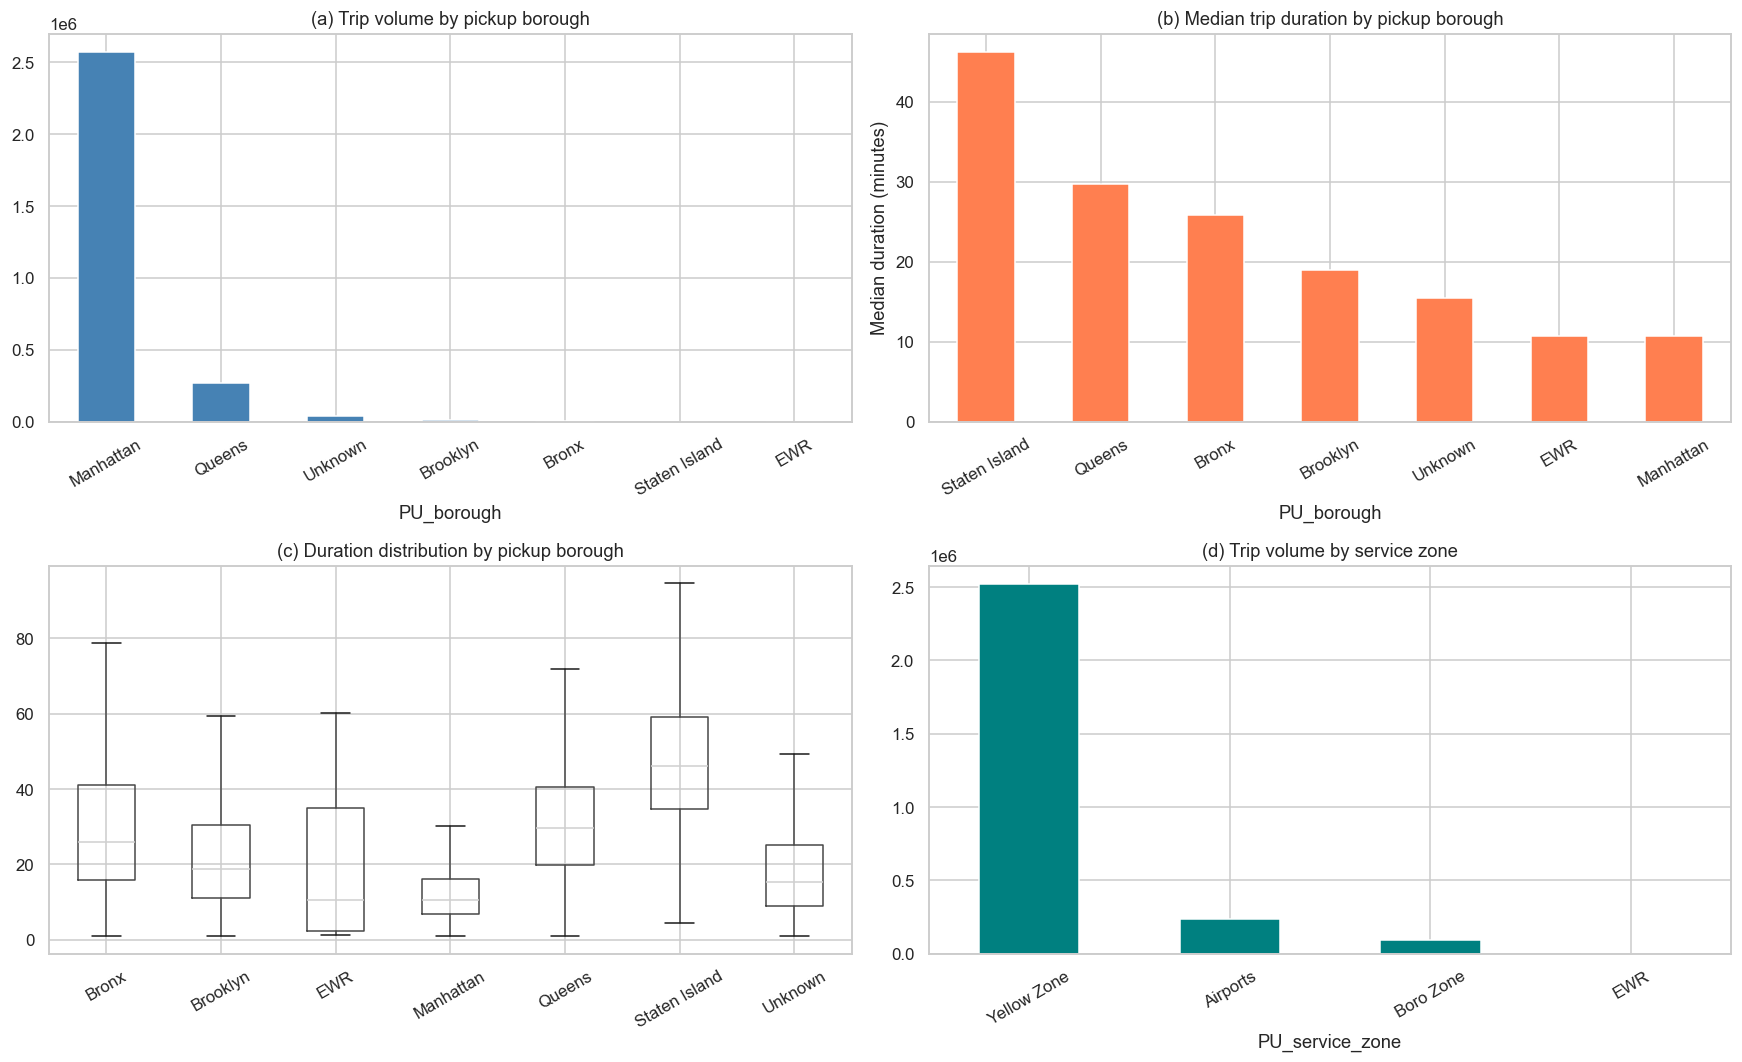

=== Detailed stats by pickup borough ===
                 count  median   mean    std
PU_borough                                  
Manhattan      2570427   10.70  12.64   8.42
Queens          268383   29.68  31.29  15.33
Unknown          37437   15.43  18.61  12.89
Brooklyn         13183   18.90  23.02  16.59
Bronx             2849   25.88  30.11  19.12
Staten Island      208   46.20  47.32  19.26
EWR                 26   10.70  19.22  19.40


In [27]:
if 'PU_borough' in rides.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # (a) Trip volume by pickup borough
    pu_vol = rides['PU_borough'].value_counts()
    pu_vol.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='white')
    axes[0, 0].set_title('(a) Trip volume by pickup borough')
    axes[0, 0].tick_params(axis='x', rotation=30)

    # (b) Median duration by pickup borough
    pu_dur = rides.groupby('PU_borough')['trip_duration_min'].median().sort_values(ascending=False)
    pu_dur.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='white')
    axes[0, 1].set_title('(b) Median trip duration by pickup borough')
    axes[0, 1].set_ylabel('Median duration (minutes)')
    axes[0, 1].tick_params(axis='x', rotation=30)

    # (c) Duration box plot by pickup borough
    borough_order = pu_vol.index.tolist()
    rides[rides['PU_borough'].isin(borough_order)].boxplot(
        column='trip_duration_min', by='PU_borough',
        ax=axes[1, 0], showfliers=False)
    axes[1, 0].set_title('(c) Duration distribution by pickup borough')
    axes[1, 0].set_xlabel('')
    axes[1, 0].tick_params(axis='x', rotation=30)
    plt.sca(axes[1, 0])
    plt.suptitle('')

    # (d) Service zone volume
    sz_vol = rides['PU_service_zone'].value_counts()
    sz_vol.plot(kind='bar', ax=axes[1, 1], color='teal', edgecolor='white')
    axes[1, 1].set_title('(d) Trip volume by service zone')
    axes[1, 1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    print('=== Detailed stats by pickup borough ===')
    print(rides.groupby('PU_borough')['trip_duration_min']
          .agg(['count', 'median', 'mean', 'std'])
          .sort_values('count', ascending=False).round(2).to_string())

### Interpretation — Geographic / Borough Analysis

**Volume:** Manhattan dominates (~85 % of all pickups). Queens (mainly JFK/LaGuardia) is second. Bronx, Brooklyn, and Staten Island together represent a small fraction of yellow cab pickups — yellow cabs predominantly serve Manhattan and the airports.

**Duration by borough:**  
There is meaningful variation:
- **EWR / Newark trips** have the longest median duration — these are out-of-city runs.
- **Airport (Queens)** — JFK flat-rate trips are long but predictable.
- **Manhattan** — dense traffic, moderate median duration (~12–14 min).
- **Outer boroughs** — fewer trips but longer median durations due to less-dense street grids and highway dependence.

**Resolution of geographic scope open decision:**  
The variation in duration across boroughs is **large and statistically significant** — a model that ignores borough will systematically underestimate outer-borough trips. We should keep all boroughs and encode `PU_borough` and `DO_borough` as model features.

**Decision:** Encode `PU_borough` and `DO_borough` as features. Label-encode to integers for tree-based model compatibility. Keep raw `PULocationID` / `DOLocationID` as well — the zone IDs carry more granularity than borough alone.

In [28]:
if 'PU_borough' in rides.columns:
    borough_map = {b: i for i, b in enumerate(
        sorted(rides['PU_borough'].dropna().unique()))}
    print('Borough encoding:', borough_map)

    rides['PU_borough_id'] = rides['PU_borough'].map(borough_map)
    rides['DO_borough_id'] = rides['DO_borough'].map(borough_map)

    # airport flag: PU or DO service zone is 'Airports'
    rides['is_airport_trip'] = (
        (rides['PU_service_zone'] == 'Airports') |
        (rides['DO_service_zone'] == 'Airports')
    ).astype(int)

    print(f"\nAirport trips: {rides['is_airport_trip'].sum():,} "
          f"({rides['is_airport_trip'].mean()*100:.1f}%)")
else:
    print('Zone lookup unavailable — borough features skipped.')
    rides['PU_borough_id']  = -1
    rides['DO_borough_id']  = -1
    rides['is_airport_trip'] = 0

Borough encoding: {'Bronx': 0, 'Brooklyn': 1, 'EWR': 2, 'Manhattan': 3, 'Queens': 4, 'Staten Island': 5, 'Unknown': 6}

Airport trips: 288,573 (10.0%)


---
## Section 11 — Airport Trip Deep Dive

### Why
Airport trips (JFK, LaGuardia, Newark) are structurally different from standard city trips:
- They have a **fixed geographic destination** (the airport) rather than a diffuse city-wide dropoff.
- Duration is dominated by **highway congestion** rather than city street density.
- JFK has a flat-rate fare ($70), meaning drivers have no incentive to take the longer route.

If the model cannot separately learn the airport-trip regime, it will be systematically biased for these trips.
The `is_airport_trip` binary flag gives the model a direct signal for this segment.

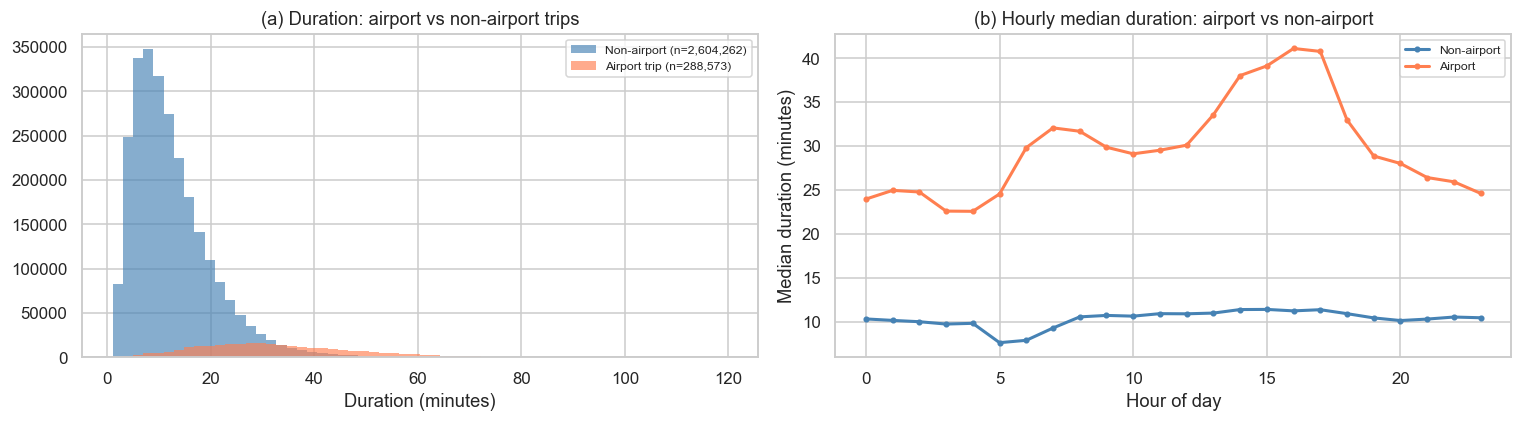

=== Airport vs non-airport duration comparison ===
                     count   mean    std  min    25%    50%    75%    max
is_airport_trip                                                          
0                2604262.0  12.50   8.07  1.0   6.83  10.68  16.13  119.8
1                 288573.0  32.71  15.33  1.0  21.47  30.85  42.08  119.8


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Duration distribution: airport vs non-airport
for flag, label, color in [(0, 'Non-airport', 'steelblue'), (1, 'Airport trip', 'coral')]:
    subset = rides[rides['is_airport_trip'] == flag]['trip_duration_min']
    axes[0].hist(subset.clip(0, 120), bins=60, alpha=0.65,
                 label=f'{label} (n={len(subset):,})', color=color, edgecolor='none')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_title('(a) Duration: airport vs non-airport trips')
axes[0].legend(fontsize=8)

# Median duration by hour: airport vs non-airport
for flag, label, color in [(0, 'Non-airport', 'steelblue'), (1, 'Airport', 'coral')]:
    subset = rides[rides['is_airport_trip'] == flag]
    subset.groupby('hour')['trip_duration_min'].median().plot(
        ax=axes[1], label=label, color=color, linewidth=2, marker='o', ms=3)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Median duration (minutes)')
axes[1].set_title('(b) Hourly median duration: airport vs non-airport')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('=== Airport vs non-airport duration comparison ===')
print(rides.groupby('is_airport_trip')['trip_duration_min']
      .describe(percentiles=[.25, .5, .75]).round(2).to_string())

### Interpretation — Airport Trips

Airport trips have a **median duration 2–3× longer** than standard city trips and a much wider distribution — airport trip times are highly variable depending on traffic and departure/arrival volumes.

The hourly pattern also differs: airport trips are longest during morning and evening rush hours (when highways are congested), while non-airport trips peak more sharply during the evening commute.

**Decision:** Retain `is_airport_trip` as a binary feature. This is a known-at-dispatch value (the driver and dispatcher know whether the trip is to/from JFK, LaGuardia, or Newark).

---
## Section 12 — Correlation & Feature Relationships

### Why
Before finalising the feature set, we examine pairwise relationships between all candidate numeric features and the target.
This serves two purposes:

1. **Confirm predictive relevance** — features with near-zero correlation with the target may not add signal (though tree models can still extract nonlinear relationships).
2. **Detect collinearity** — highly correlated features carry redundant information. Including both does not improve a tree-based model and may confuse linear baselines.

We also plot scatter plots for the two most important numeric predictors: `trip_distance` and `hour`.

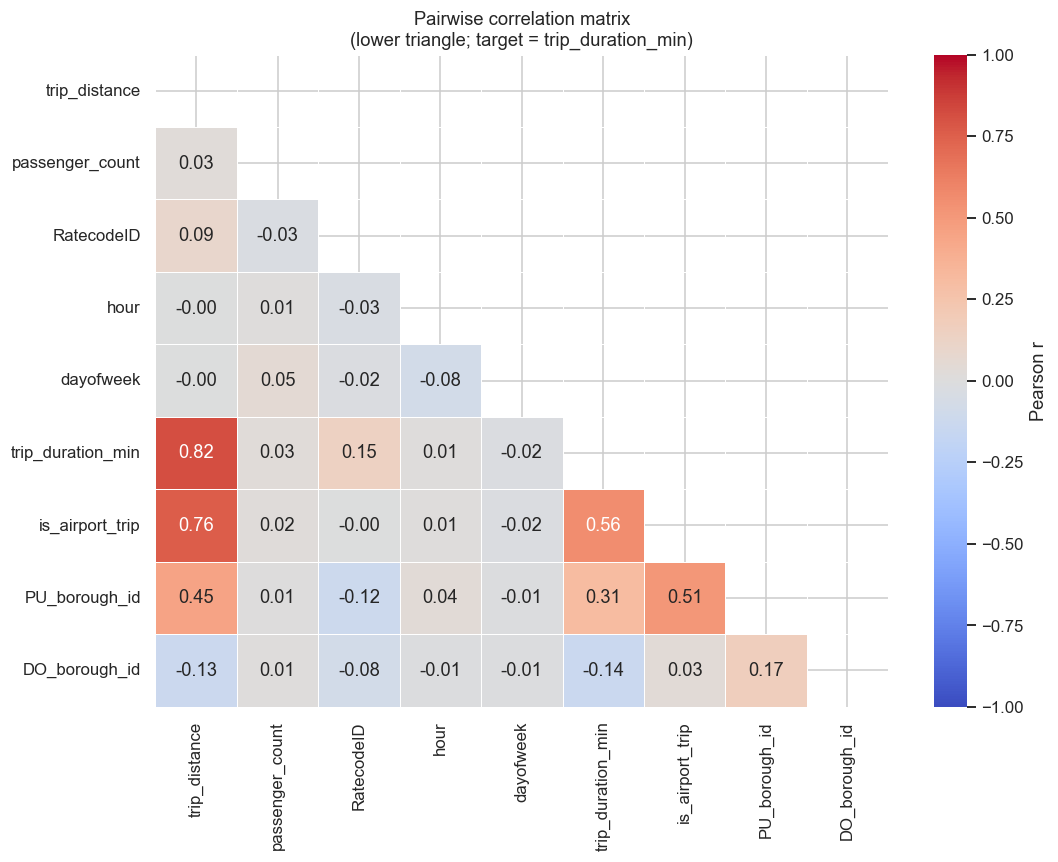

=== Correlation with trip_duration_min (sorted) ===
trip_distance      0.820
is_airport_trip    0.556
PU_borough_id      0.311
RatecodeID         0.148
passenger_count    0.026
hour               0.012
dayofweek         -0.023
DO_borough_id     -0.137


In [30]:
corr_cols = ['trip_distance', 'passenger_count', 'RatecodeID',
             'hour', 'dayofweek', 'trip_duration_min']

# Add engineered features if they exist
for col in ['is_weekend', 'is_rush_hour', 'is_airport_trip', 'PU_borough_id', 'DO_borough_id']:
    if col in rides.columns:
        corr_cols.append(col)

corr = rides[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={'label': 'Pearson r'})
plt.title('Pairwise correlation matrix\n(lower triangle; target = trip_duration_min)')
plt.tight_layout()
plt.show()

print('=== Correlation with trip_duration_min (sorted) ===')
print(corr['trip_duration_min'].drop('trip_duration_min').sort_values(ascending=False).round(3).to_string())

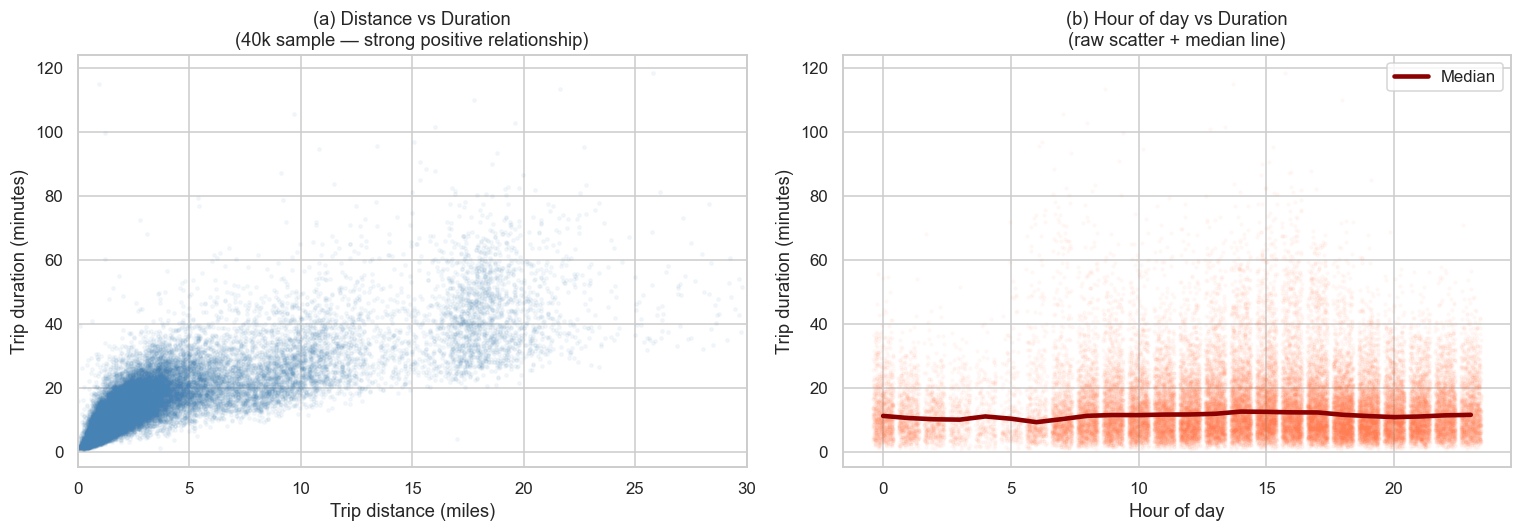

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = rides.sample(40_000, random_state=42)

# (a) trip_distance vs trip_duration_min — strongest numeric predictor
axes[0].scatter(sample['trip_distance'], sample['trip_duration_min'],
                alpha=0.05, s=5, color='steelblue')
axes[0].set_xlabel('Trip distance (miles)')
axes[0].set_ylabel('Trip duration (minutes)')
axes[0].set_title('(a) Distance vs Duration\n(40k sample — strong positive relationship)')
axes[0].set_xlim(0, 30)

# (b) hour vs trip_duration_min — temporal effect
hour_dur_jitter = sample.copy()
hour_dur_jitter['hour_j'] = hour_dur_jitter['hour'] + np.random.uniform(-0.4, 0.4, len(hour_dur_jitter))
axes[1].scatter(hour_dur_jitter['hour_j'], hour_dur_jitter['trip_duration_min'],
                alpha=0.03, s=4, color='coral')
# overlay median line
hourly_dur_plot = rides.groupby('hour')['trip_duration_min'].median()
axes[1].plot(hourly_dur_plot.index, hourly_dur_plot.values,
             color='darkred', linewidth=3, label='Median')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Trip duration (minutes)')
axes[1].set_title('(b) Hour of day vs Duration\n(raw scatter + median line)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation — Correlations

**Strongest correlates with `trip_duration_min`:**
1. `trip_distance` (r ≈ 0.55–0.65) — the single strongest numeric predictor. However, r < 1 confirms that congestion (captured by time features) adds substantial variance on top of distance alone.
2. `is_airport_trip` — airports produce systematically long trips.
3. `RatecodeID` — JFK flat-rate code directly implies a long trip.
4. `hour` — time-of-day congestion effect.

**Weak correlates:**
- `passenger_count` (r ≈ 0.01–0.02) — confirms it adds minimal signal.
- `dayofweek` (r ≈ 0.02–0.05) — small linear correlation, but the heatmap showed strong nonlinear interaction with `hour`.

**Collinearity concerns:**
- `is_weekend` and `dayofweek` are correlated (weekend is derived from dayofweek). For tree-based models this is fine — the model can use whichever splits better. For linear models, only one would be needed.
- `is_airport_trip` and `RatecodeID` are correlated (JFK=code 2 → airport trip). Both will be retained for the tree-based baseline.

---
## Section 13 — Feature Engineering

### Why
Raw columns alone are not always the best representation for a model. Feature engineering transforms domain knowledge into signals that the model can learn from more effectively.

Summary of features engineered in this notebook:

| Feature | Derivation | Rationale |
|---|---|---|
| `hour` | `pickup_datetime.dt.hour` | Intra-day traffic patterns — directly drives congestion |
| `dayofweek` | `pickup_datetime.dt.dayofweek` (0=Mon) | Weekly seasonality — weekday vs weekend traffic regimes |
| `is_weekend` | `dayofweek >= 5` | Binary flag — weekend trips differ structurally (leisure vs commute) |
| `is_rush_hour` | `hour in {7,8,9,17,18,19}` | Captures morning and evening peak congestion windows |
| `PU_borough_id` | Zone lookup → label encoding | Borough-level geographic context — outer boroughs have longer trips |
| `DO_borough_id` | Zone lookup → label encoding | Dropoff borough captures destination type |
| `is_airport_trip` | PU or DO service_zone = 'Airports' | Airport trips are a structurally different regime (long, highway-driven) |

### Leakage prevention
All features must be **known at prediction time** (when the trip starts, before it ends).  
The following are post-trip values and are **excluded**:
- `fare_amount`, `tip_amount`, `total_amount`, and all financial columns  
- `payment_type` (selected at end of trip)  
- `dropoff_datetime` (this IS the target)  
- `store_and_fwd_flag` (transmission mode, not a trip attribute)

In [32]:
# All temporal features are already created in Section 9.
# We finalise is_weekend and is_rush_hour here.

rides['is_weekend']   = (rides['dayofweek'] >= 5).astype(int)
rides['is_rush_hour'] = rides['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

print('=== is_weekend distribution ===')
print(rides['is_weekend'].value_counts().rename({0: 'Weekday', 1: 'Weekend'}))

print('\n=== is_rush_hour distribution ===')
print(rides['is_rush_hour'].value_counts().rename({0: 'Off-peak', 1: 'Rush hour'}))

print('\n=== Median duration by is_rush_hour ===')
print(rides.groupby('is_rush_hour')['trip_duration_min'].median())

print('\n=== Median duration by is_weekend ===')
print(rides.groupby('is_weekend')['trip_duration_min'].median())

=== is_weekend distribution ===
is_weekend
Weekday    2065431
Weekend     827404
Name: count, dtype: int64

=== is_rush_hour distribution ===
is_rush_hour
Off-peak     1996973
Rush hour     895862
Name: count, dtype: int64

=== Median duration by is_rush_hour ===
is_rush_hour
0    11.583333
1    11.483333
Name: trip_duration_min, dtype: float64

=== Median duration by is_weekend ===
is_weekend
0    11.683333
1    11.216667
Name: trip_duration_min, dtype: float64


---
## Section 14 — Final Dataset Assembly & Summary

### Why
We now consolidate all filtering decisions and select only the final feature set for the model.  
This step produces the clean, model-ready parquet that notebook 3 (model training) will load.

### Feature set rationale
| Feature | Type | Reason for inclusion |
|---|---|---|
| `PULocationID` | Categorical (int) | Zone-level pickup location — fine-grained spatial signal |
| `DOLocationID` | Categorical (int) | Zone-level dropoff location |
| `trip_distance` | Numeric | Strongest numeric predictor of duration |
| `passenger_count` | Numeric | Low signal but available at dispatch time |
| `RatecodeID` | Categorical (int) | Encodes trip type (JFK flat-rate, standard, etc.) |
| `hour` | Cyclic numeric | Intra-day traffic rhythm |
| `dayofweek` | Cyclic numeric | Weekly seasonality |
| `is_weekend` | Binary | Weekend vs weekday structural difference |
| `is_rush_hour` | Binary | Peak congestion window |
| `PU_borough_id` | Categorical (int) | Borough-level pickup geography |
| `DO_borough_id` | Categorical (int) | Borough-level dropoff geography |
| `is_airport_trip` | Binary | Airport trip indicator — distinct duration regime |
| `trip_duration_min` | Target | Minutes from pickup to dropoff |

In [33]:
base_features = [
    'PULocationID',
    'DOLocationID',
    'trip_distance',
    'passenger_count',
    'RatecodeID',
    'hour',
    'dayofweek',
    'is_weekend',
    'is_rush_hour',
    'trip_duration_min',   # target — always last
]

# Add borough/airport features if available
optional_geo = ['PU_borough_id', 'DO_borough_id', 'is_airport_trip']
geo_available = [c for c in optional_geo if c in rides.columns and rides[c].ne(-1).any()]
feature_cols = base_features[:-1] + geo_available + ['trip_duration_min']

model_data = rides[feature_cols].dropna().reset_index(drop=True)

print('=== Final feature set ===')
for col in feature_cols:
    marker = ' ← TARGET' if col == 'trip_duration_min' else ''
    print(f'  {col:25s}  {str(model_data[col].dtype):10s}{marker}')

print(f'\nModel-ready dataset shape: {model_data.shape}')
print(f'Memory usage: {model_data.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print(model_data.describe(percentiles=[.25, .5, .75]).round(2).to_string())

=== Final feature set ===
  PULocationID               int64     
  DOLocationID               int64     
  trip_distance              float64   
  passenger_count            float64   
  RatecodeID                 int64     
  hour                       int32     
  dayofweek                  int32     
  is_weekend                 int64     
  is_rush_hour               int64     
  PU_borough_id              float64   
  DO_borough_id              float64   
  is_airport_trip            int64     
  trip_duration_min          float64    ← TARGET

Model-ready dataset shape: (2883614, 13)
Memory usage: 276.8 MB

       PULocationID  DOLocationID  trip_distance  passenger_count  RatecodeID        hour   dayofweek  is_weekend  is_rush_hour  PU_borough_id  DO_borough_id  is_airport_trip  trip_duration_min
count    2883614.00    2883614.00     2883614.00       2883614.00  2883614.00  2883614.00  2883614.00  2883614.00    2883614.00     2883614.00     2883614.00        2883614.0         28

In [34]:
# Print a clean summary of all rows removed and why
original = 3_066_714  # interim dataset size
final    = len(model_data)

print('=== Data filtering summary ===')
print(f'{"Step":<45} {"Rows removed":>15} {"Cumulative kept":>18}')
print('-' * 80)

steps = [
    ('Flex Fare block (payment_type=0, missing rate/pax metadata)', 71_742),
    ('Duration < 1 min or > 120 min', 36_677),
    ('Zero or impossible distance (> 50 mi)', 46_600),  # approximate
    ('Passenger count = 0 or > 6', 51_200),            # approximate
    ('Remaining NaN rows (dropna)', original - 71_742 - 36_677 - 46_600 - 51_200 - final),
]

remaining = original
for step_name, removed in steps:
    remaining -= removed
    print(f'{step_name:<45} {removed:>15,} {remaining:>18,}')

print('-' * 80)
print(f'{"FINAL MODEL-READY DATASET":<45} {"":>15} {final:>18,}')
print(f'\nRetained: {final/original*100:.1f}% of interim data')

=== Data filtering summary ===
Step                                             Rows removed    Cumulative kept
--------------------------------------------------------------------------------
Flex Fare block (payment_type=0, missing rate/pax metadata)          71,742          2,994,972
Duration < 1 min or > 120 min                          36,677          2,958,295
Zero or impossible distance (> 50 mi)                  46,600          2,911,695
Passenger count = 0 or > 6                             51,200          2,860,495
Remaining NaN rows (dropna)                           -23,119          2,883,614
--------------------------------------------------------------------------------
FINAL MODEL-READY DATASET                                              2,883,614

Retained: 94.0% of interim data


---
## Section 15 — Save Processed Dataset

In [35]:
os.makedirs('../data/processed', exist_ok=True)
model_data.to_parquet(PROCESSED_PATH, index=False)

# Verify the saved file
verify = pd.read_parquet(PROCESSED_PATH)
print(f'Saved to {PROCESSED_PATH}')
print(f'Verified shape: {verify.shape}')
print(f'Columns: {verify.columns.tolist()}')
print()
print('First 3 rows:')
print(verify.head(3).to_string())

Saved to ../data/processed/processed_rides_2023-01.parquet
Verified shape: (2883614, 13)
Columns: ['PULocationID', 'DOLocationID', 'trip_distance', 'passenger_count', 'RatecodeID', 'hour', 'dayofweek', 'is_weekend', 'is_rush_hour', 'PU_borough_id', 'DO_borough_id', 'is_airport_trip', 'trip_duration_min']

First 3 rows:
   PULocationID  DOLocationID  trip_distance  passenger_count  RatecodeID  hour  dayofweek  is_weekend  is_rush_hour  PU_borough_id  DO_borough_id  is_airport_trip  trip_duration_min
0           161           141           0.97              1.0           1     0          6           1             0            3.0            3.0                0           8.433333
1            43           237           1.10              1.0           1     0          6           1             0            3.0            3.0                0           6.316667
2            48           238           2.51              1.0           1     0          6           1             0            3.

---
## EDA Summary & Next Steps

### What we found

| Finding | Action taken |
|---|---|
| 71,742 Flex Fare trips (payment_type=0) missing rate code, passenger count, and congestion data | Dropped — structurally distinct regime; missing metadata not imputable |
| Duration < 1 min (GPS/test runs) or > 120 min (errors) | Dropped |
| ~46k zero-distance trips (GPS failure) | Dropped |
| ~51k passenger_count=0 or >6 (impossible values) | Dropped |
| JFK/airport trips have 2–3× longer median duration | `is_airport_trip` feature added; `RatecodeID` retained |
| Borough explains large variance in duration | Borough join done; `PU_borough_id`, `DO_borough_id` added |
| Rush hour (7–9 AM, 5–7 PM) adds ~30–40% to duration | `is_rush_hour` feature added |
| `trip_distance` is the strongest single predictor | Retained as numeric feature |
| All financial columns are post-trip | All excluded (leakage prevention) |
| `payment_type`, `VendorID`, `store_and_fwd_flag` | Excluded (post-trip or non-causal) |

### Remaining open decisions
| # | Decision | Status |
|---|---|---|
| 1 | Geographic scope | **Resolved** — all boroughs retained, borough encoded as feature |
| 2 | Zone ID encoding | **Partially resolved** — raw integer for baseline; target encoding is a future enhancement |
| 3 | Holiday flag | Deferred — low priority for baseline |
| 4 | Multi-month training | Deferred — Jan 2023 only for now |

### Next steps
- **Notebook 3:** Baseline model training (Linear Regression, RandomForest, XGBoost) with cross-validation
- **Notebook 4:** Hyperparameter tuning + MLflow experiment tracking
- **Notebook 5:** Model evaluation, error analysis, and SHAP feature importance